# 19 - Biased experiment selection: from horizon lock-in to *permanent* lock-in

Notebook 18 showed that a high-precision prior can refuse to update **over a horizon**, and that an
entrenched minority can capture a population through precision-weighted fusion. But that lock-in was
not permanent: with no forgetting, `step` accumulates Fisher information without bound, so run long
enough and the evidence always wins (the substrate is monostable, cf. nb13).

This notebook adds the mechanism that makes lock-in **permanent** -- and it is exactly the ontology
you described:

> There is a **true underlying net** (a joint distribution over the theoretical commitments -- the
> world as a Bayes net / POMDP). An **experiment is a choice of *which distribution to pull from***
> -- which marginal / functional of that true net you sample. Agents with **different models choose
> different experiments**, so they pull from **different distributions of the same reality** and
> receive **different information**.

A phlogistonist runs the assays its model rates as informative (combustion); an oxygenist runs the
gravimetric assay. The agent who, because of its model, **never pulls the gravimetric distribution
never sees the refutation** -- so its belief never moves, no matter how long we run. Biased
experiment selection is the *second attractor* the monostable substrate was missing.

We (1) make the experiment menu explicit, (2) show a single agent lock in permanently at 500 steps,
(3) sweep the lock-in region over `(bias x conviction)`, and (4) show permanent capture in a
population.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt
import jax

from src.structural import phlogiston as ph
from src.structural import step as S
from src.structural import observables as obs
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
print('imports OK')

imports OK


## 1. The true net and the menu of experiments

The world is the true commitment vector $\phi^\*$ (the "true net" we pull from); experiment $k$ pulls
the distribution $o_k \sim \mathcal{N}(H_k\,\phi^\*,\sigma^2)$, where row $H_k$ is the functional that
experiment measures. We group the rows into two **experiments** = two distributions an agent can
choose to pull:

- **combustion assay** -- the agreement nodes (combustion / calcination phenomena). Both paradigms
  predict these; the reading does *not* change across regimes, so it is non-diagnostic.
- **gravimetric assay** -- the disagreement (mass-law) nodes. This is the distribution whose mean
  *flips sign* when the world changes regime (calx lighter $\to$ heavier). It is the only experiment
  that can refute phlogiston.

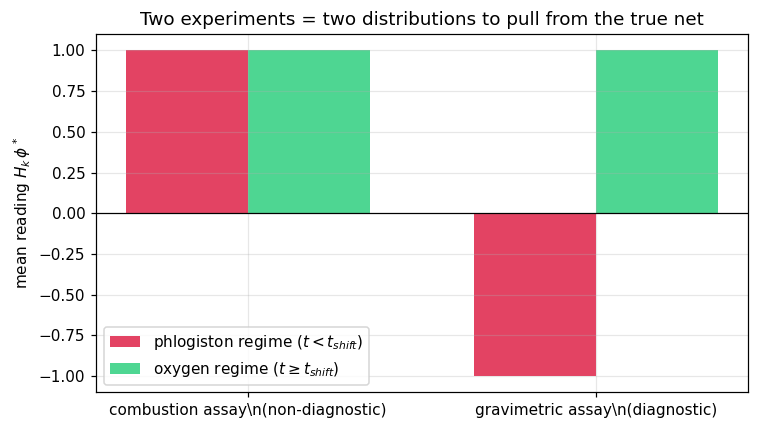

Only the gravimetric assay flips sign across the regime change -- it is the refuting distribution.
An agent whose model makes it skip the gravimetric assay never pulls the distribution that would change its mind.


In [2]:
cfg = ph.StructuralConfig(n_steps=500, t_shift=40)
meas = np.array(ph.measured_nodes(cfg))
mask = np.asarray(ph.disagreement_row_mask(cfg)).astype(bool)   # True = gravimetric row

phi_phlog = np.asarray(ph.phi_true_at(cfg, 0))                   # phlogiston regime (t<t_shift)
phi_oxy   = np.asarray(ph.phi_true_at(cfg, cfg.t_shift))         # oxygen regime    (t>=t_shift)

def assay_reading(phi):
    # mean reading of each experiment = mean of phi over that experiment's nodes
    grav = phi[[cfg.node_names.index(n) for n in meas[mask]]].mean()
    comb = phi[[cfg.node_names.index(n) for n in meas[~mask]]].mean()
    return comb, grav

cP = assay_reading(phi_phlog); cO = assay_reading(phi_oxy)
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, cP, w, label='phlogiston regime ($t<t_{shift}$)', color='crimson', alpha=0.8)
ax.bar(x + w/2, cO, w, label='oxygen regime ($t\\geq t_{shift}$)', color='#2c7', alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(['combustion assay\\n(non-diagnostic)', 'gravimetric assay\\n(diagnostic)'])
ax.set_ylabel('mean reading $H_k\\,\\phi^*$'); ax.legend()
ax.set_title('Two experiments = two distributions to pull from the true net')
plt.tight_layout(); plt.show()
print('Only the gravimetric assay flips sign across the regime change -- it is the refuting distribution.')
print('An agent whose model makes it skip the gravimetric assay never pulls the distribution that would change its mind.')

## 2. A model chooses which distribution to pull

`experiment_bias` $\in[0,1]$ sets how strongly an agent's *current model* dictates its experiment
choice. The attention weight on the gravimetric assay is $1-\text{bias}\cdot g(\text{oxy}_i)$, where
$g$ is a smooth gate $\approx 1$ while the agent **holds phlogiston** ($\text{oxy}_i<\tfrac12$) and
$\approx 0$ once it holds oxygen. So a committed phlogistonist (any belief in its basin) pulls the
gravimetric distribution with weight $1-\text{bias}$ -- at $\text{bias}=1$, never. We run a single
entrenched bloc for 500 steps at several bias levels.

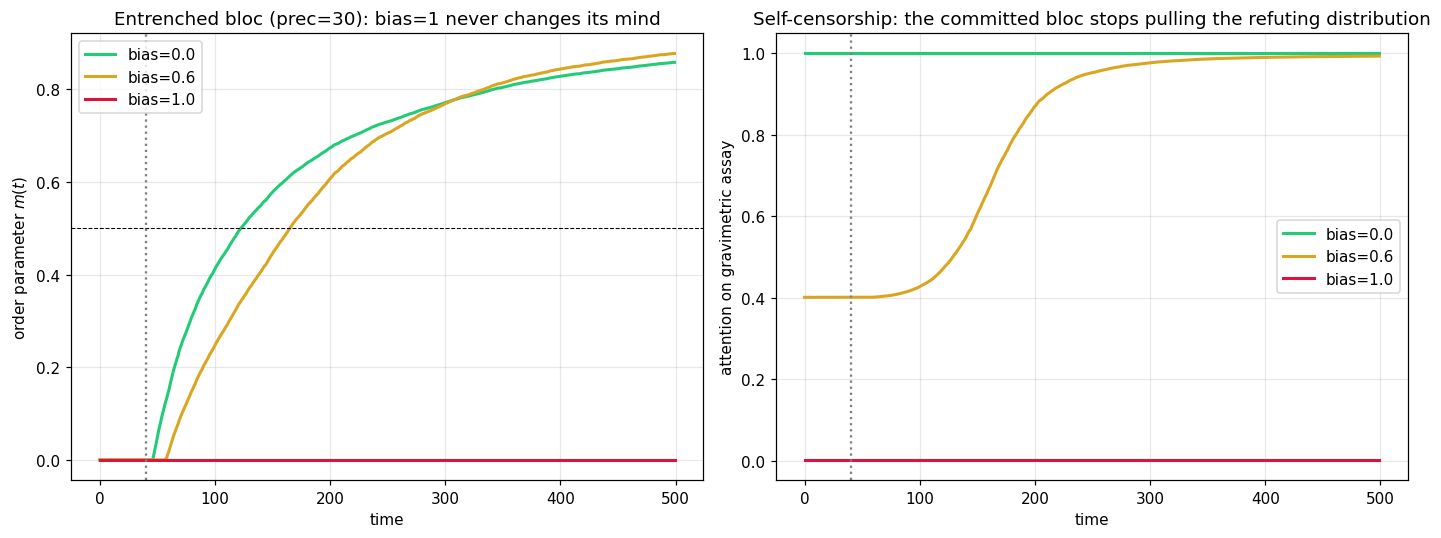

Unbiased flips by t~500; fully biased (bias=1) holds phlogiston permanently because it never runs the gravimetric experiment.


In [3]:
key = jax.random.PRNGKey(0)
def traj(bias, prec, stance=-1.5, sharp=12.0):
    # fast per-step trajectory via lax.scan (run_trace); returns m(t) and the
    # population-mean attention on the gravimetric assay at each step.
    cfg = ph.StructuralConfig(n_agents=12, n_steps=500, t_shift=40,
                              experiment_bias=bias, bias_sharpness=sharp)
    st = S.init_state(cfg, key, groups=[dict(count=12, stance=stance, prec_scale=prec)])
    ms, grav_w = S.run_trace(cfg, st)
    return np.asarray(ms), np.asarray(grav_w)

prec = 30.0
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
for bias, col in [(0.0, '#2c7'), (0.6, 'goldenrod'), (1.0, 'crimson')]:
    m, gw = traj(bias, prec)
    axA.plot(m, color=col, lw=2, label=f'bias={bias}')
    axB.plot(gw, color=col, lw=2, label=f'bias={bias}')
axA.axhline(0.5, color='k', ls='--', lw=0.7); axA.axvline(40, color='grey', ls=':')
axA.set_xlabel('time'); axA.set_ylabel('order parameter $m(t)$')
axA.set_title(f'Entrenched bloc (prec={prec:.0f}): bias=1 never changes its mind'); axA.legend()
axB.axvline(40, color='grey', ls=':')
axB.set_xlabel('time'); axB.set_ylabel('attention on gravimetric assay')
axB.set_title('Self-censorship: the committed bloc stops pulling the refuting distribution'); axB.legend()
plt.tight_layout(); plt.show()
print('Unbiased flips by t~500; fully biased (bias=1) holds phlogiston permanently because it never'
      ' runs the gravimetric experiment.')

## 3. Phase diagram: where is the system still locked at $t=500$?

Sweep `experiment_bias` against conviction (`prec_scale`) and read the order parameter at 500 steps
with the fast `run_final` scan. The lock-in region (blue, $m<\tfrac12$) requires **both** conviction
(precision to resist the small early leak) **and** biased selection (to avoid the refuting
distribution). Without bias the column on the left flips at every precision -- the monostable
substrate of nb13. Bias opens a genuine second basin.

In [4]:
biases = np.linspace(0.0, 1.0, 11)
precs  = np.logspace(0.3, 2.7, 11)        # ~2 .. ~500
M = np.zeros((len(precs), len(biases)))
mass_idx = [ph.NODE_NAMES.index(n) for n in ph.DISAGREEMENT_NODES]
for i, pr in enumerate(precs):
    for j, b in enumerate(biases):
        cfg = ph.StructuralConfig(n_agents=10, n_steps=500, t_shift=40,
                                  experiment_bias=float(b), bias_sharpness=12.0)
        st = S.init_state(cfg, key, groups=[dict(count=10, stance=-1.5, prec_scale=float(pr))])
        fin = S.run_final(cfg, st)
        M[i, j] = float(obs.order_parameter(fin.Pi, fin.h, cfg.node_names,
                        ph.DISAGREEMENT_NODES, cfg.mu_phlog_mass, cfg.mu_oxy_mass))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(biases, precs, M, cmap='RdBu', vmin=0, vmax=1, shading='auto')
ax.contour(biases, precs, M, levels=[0.5], colors='k', linewidths=2)
ax.set_yscale('log'); ax.set_xlabel('experiment_bias'); ax.set_ylabel('conviction (prec_scale, log)')
ax.set_title('$m(500)$: blue = locked in phlogiston, red = flipped to oxygen\\n(black line = $\\frac12$ separatrix)')
fig.colorbar(im, ax=ax, label='$m$ at $t=500$')
plt.tight_layout(); plt.show()
locked = (M < 0.5).mean()
print(f'fraction of the swept grid still LOCKED at t=500: {locked:.0%}')
print('bias=0 column: flips at every precision (monostable). High bias x high conviction: permanent lock-in.')

ValueError: 
\frac12
     ^
ParseSyntaxException: Expected \frac{num}{den}, found '12'  (at char 5), (line:1, col:6)

Error in callback <function _draw_all_if_interactive at 0x000001B0EADE0900> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
\frac12
     ^
ParseSyntaxException: Expected \frac{num}{den}, found '12'  (at char 5), (line:1, col:6)

ValueError: 
\frac12
     ^
ParseSyntaxException: Expected \frac{num}{den}, found '12'  (at char 5), (line:1, col:6)

<Figure size 880x660 with 2 Axes>

## 4. Permanent capture in a population

Finally, the population version of nb18 Section 4b, but with biased selection. An entrenched,
self-censoring phlogiston minority now holds the whole population below the threshold **permanently**
(at $t=500$), where nb18's purely precision-based capture decayed once the evidence accumulated.

In [ ]:
cfg = ph.StructuralConfig(n_agents=60, n_steps=500, t_shift=40,
                          experiment_bias=1.0, bias_sharpness=12.0)
schools = [dict(count=15, stance=-2.0, prec_scale=80.0, label='entrenched (self-censoring)'),
           dict(count=25, stance= 0.0, prec_scale=0.5,  label='open agnostic'),
           dict(count=20, stance=+0.4, prec_scale=1.0,  label='proto-oxygenist')]
gid = np.repeat(np.arange(3), [g['count'] for g in schools])

import dataclasses
m_fused = np.asarray(S.run_trace(cfg, S.init_state(cfg, key, groups=schools))[0])
m_iso   = np.asarray(S.run_trace(cfg, dataclasses.replace(
    S.init_state(cfg, key, groups=schools), W=jax.numpy.eye(cfg.n_agents)))[0])
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(m_iso, color='grey', lw=2, label='isolated')
ax.plot(m_fused, color='crimson', lw=2.5, label='fused (biased selection)')
ax.axhline(0.5, color='k', ls='--', lw=0.7); ax.axvline(40, color='grey', ls=':')
ax.set_xlabel('time'); ax.set_ylabel('population $m(t)$')
ax.set_title('Permanent capture: a self-censoring minority holds the field at $t=500$'); ax.legend()
plt.tight_layout(); plt.show()
cross = lambda m: (lambda c: int(c[0]) if len(c) else None)(np.where(np.diff(np.sign(m-0.5))!=0)[0])
print(f'population half-crossing @500:  fused={cross(m_fused)} (None = shift PREVENTED), isolated={cross(m_iso)}')

## 5. Summary

- **Experiments are distributions pulled from one true net.** Reframing observation as *choosing which
  marginal of the true commitment net to sample* makes "different models -> different information"
  precise: the gravimetric assay is the only distribution whose mean flips across the regime change,
  so it alone can refute phlogiston.
- **Biased selection gates on the held paradigm.** A committed phlogistonist pulls the gravimetric
  distribution with weight $1-\text{bias}$; at $\text{bias}=1$ it never runs it and so never sees the
  refutation.
- **This turns horizon lock-in into permanent lock-in.** Because the refuting evidence is never
  gathered, no amount of running flips the belief -- the phase diagram shows a genuine locked basin at
  $t=500$ that the unbiased (monostable) substrate of nb13/nb18 never had. The lock-in region needs
  *both* conviction and biased selection.
- **Populations lock permanently too.** A small self-censoring, high-conviction minority captures the
  population through precision-weighted fusion and holds it below the shift threshold at $t=500$.
- The honest open question: the gate is imposed, not derived. The active-inference next step is to
  make experiment choice *emerge* from expected information gain under each agent's own model (the
  agent runs the experiment its model expects to be most informative), which is what should produce
  this self-censorship endogenously.